In [ ]:
import numpy as np
import math
from numba import njit
import matplotlib.pyplot as plt

### POWER SPECTRA ###

# Get the power spectrum of a time series
def power_spectrum(input, sampling_frequency):
    fourier = np.fft.fft(input)
    fftfreq = np.fft.fftfreq(len(input), 1 / sampling_frequency)

    power = np.square(np.abs(fourier)) / (sampling_frequency * len(input))

    # Keep only the positive frequencies
    pos_mask = fftfreq >= 0
    return fftfreq[pos_mask], power[pos_mask]

# Get the average power spectrum across all node time series
def average_spectrum(time_series, sampling_frequency = 1000):

    frequency_bins, average_spectrum = power_spectrum(time_series[0], sampling_frequency)

    for i in range(len(time_series) - 1):

        this_spectrum = power_spectrum(time_series[i + 1], sampling_frequency)[1]
        average_spectrum = np.add(this_spectrum, average_spectrum)

    average_spectrum = average_spectrum / len(time_series)

    return frequency_bins, average_spectrum

# Get the power spectrum of the average time series
def node_averaged_spectrum(time_series, sampling_frequency = 1000):

    node_averaged_time_series = np.mean(time_series, axis = 0)

    frequency_bins, average_spectrum = power_spectrum(node_averaged_time_series, sampling_frequency)

    return frequency_bins, average_spectrum


### MAIN ###


# Create a random matrix satisfying Dale's law,
# with approximately the same effective weight scale as the original matrix
# def random_matrix(size, var, connection_probability):

#     exc_fraction = 0.8
#     inh_fraction = 1.0 - exc_fraction

#     # Excitatory and inhibitory row scales
#     exc_scale = 1.0
#     inh_scale = exc_fraction / inh_fraction   # = 4.0 for 80/20 balance

#     # Choose sigma so that E[w^2] = var over nonzero entries
#     sigma2 = var / (exc_fraction * exc_scale**2 + inh_fraction * inh_scale**2)
#     sigma = np.sqrt(sigma2)

#     # Assign neuron types by row
#     n_exc = int(np.round(exc_fraction * size))
#     neuron_signs = np.ones(size)
#     neuron_signs[n_exc:] = -1
#     np.random.shuffle(neuron_signs)

#     # Draw positive magnitudes
#     matrix = np.abs(np.random.normal(0, sigma, (size, size)))

#     # Apply row type and scale
#     for i in range(size):
#         if neuron_signs[i] > 0:
#             matrix[i] *= exc_scale
#         else:
#             matrix[i] *= inh_scale
#         matrix[i] *= neuron_signs[i]

#     # Apply Erdős–Rényi sparsity and remove self-connections
#     for i in range(size):
#         for j in range(size):
#             if (np.random.uniform() > connection_probability) or i == j:
#                 matrix[i][j] = 0

#     return matrix

# Create a random Guassian matrix with mean = 0 and variance = var, with every row mean = 0
def random_matrix(size, var, connection_probability):

    # Create matrix
    matrix = np.array([np.random.normal(0, var**0.5, size) for x in range(size)])

    for i in range(len(matrix)):
        for j in range(len(matrix)):

            if (np.random.uniform() > connection_probability) or i == j:

                matrix[i][j] = 0

    # Force the rows and overall matrix to have mean 0
    new_matrix = np.copy(matrix)

    for row in range(len(matrix)):

        row_sum = np.sum(matrix[row])

        for column in range(len(matrix)):

            new_matrix[row][column] -= row_sum / len(matrix)

    return new_matrix

# Stochastic differential equation
@njit
def differential_equation(node_index, parameter_array, state_array, adjacency_matrix):

    Vi = state_array[node_index]
    b = parameter_array[node_index][0]
    Di = parameter_array[node_index][1]

    sum_term = 0
    for i in range(len(state_array)):

        Vj = state_array[i]

        sum_term += adjacency_matrix[node_index][i] * 0.5 * (1 + math.erf(b*Vj))

    return -Vi + sum_term, math.sqrt(2*Di)

# Perform Euler-Maruyama integration to create a time series
@njit
def integrate(end_time, dt, state_array, parameter_array, ODE, matrix):

    state = state_array
    results = np.zeros((len(state),int(end_time/dt)))
    results[0:len(state)+1,0] = state

    for t in range(int(end_time/dt) - 1):

            # Get the derivitives
            derivatives = []

            for i in range(len(matrix)):

                derivatives.append(ODE(i, parameter_array, state, matrix))

            # Do the stuff
            dws = np.zeros(len(derivatives))
            for i in range(len(derivatives)):
                dws[i] = np.random.normal(0,np.sqrt(dt))

            new_state = np.zeros(len(derivatives))
            for i in range(len(derivatives)):
                new_state[i] = state[i] + dt * derivatives[i][0] + dws[i] * derivatives[i][1]

            state = new_state

            results[0:len(state)+1,t+1] = new_state

    return results

# Create a time series and spectrum
class Simulation:

    def __init__(self, starting_state, parameter_array, differential_equation, matrix, end_time, dt, node_averaged):

        self.simulate(starting_state, parameter_array, differential_equation, matrix, end_time, dt, node_averaged)

    def simulate(self, starting_state, parameter_array, differential_equation, matrix, end_time, dt, node_averaged):

        # Time units = seconds
        time_series = integrate(end_time, dt, starting_state, parameter_array, differential_equation, matrix)
        self.time_series = time_series

        # Sampling each 100th of a second
        if node_averaged == False:
            spectrum = average_spectrum(time_series[:,1000:len(time_series[0])], int(1 / dt))
        else:
            spectrum = node_averaged_spectrum(time_series[:,1000:len(time_series[0])], int(1 / dt))
        self.spectrum = spectrum

In [ ]:
# Create points for theoretical power spectrum without noise in the spectral radius
def theoretical_ps_nn(N, p, weights_variance, D, beta, x_min, x_max, resolution):

    # Get spectral radius
    r = np.sqrt(((N-1) * p * weights_variance * beta**2) / np.pi ) # N = number of nodes, p = connection probability, s = weight sd/spread

    x_values = np.linspace(x_min, x_max, resolution) # x values are f (frequency)

    y_values = (2*D / (1 - r**2 + (2 * np.pi * x_values)**2)) #* 1 / N # this term for if spectra of average activity

    return x_values, y_values

# Create points for theoretical power spectrum without noise in the spectral radius
def theoretical_ps_wn(N, p, weights_variance, D, beta, x_min, x_max, resolution):

    r = np.sqrt(((N-1) * p * weights_variance * beta**2) / (np.pi * np.sqrt(1 + 4 * (D) * (beta**2))))

    x_values = np.linspace(x_min, x_max, resolution) # x values are f (frequency)

    y_values = (2*D / (1 - r**2 + (2 * np.pi * x_values)**2)) #* 1 / N # this term for if spectra of average activity

    return x_values, y_values

# Weight variance test
def wv_test(samples_per_trial, variance_regimes, starting_state, parameter_array, differential_equation, size, noise, connection_probability, theoretical_contains_D, end_time, dt, node_averaged):

    simulations = []

    trials = len(variance_regimes)

    for trial in range(trials):

        var = variance_regimes[trial]

        parameter_array[:,1] = noise

        samples = []

        for sample in range(samples_per_trial):

            matrix = random_matrix(size, var, connection_probability)

            this_sim = Simulation(starting_state, parameter_array, differential_equation, matrix, end_time, dt, node_averaged)

            this_sim.var = var

            samples.append(this_sim)

        spectra = np.array([sample.spectrum[1] for sample in samples])

        frequency_axis = samples[0].spectrum[0]

        average_spectrum = np.mean(spectra, axis = 0)

        variance = np.var(spectra, axis = 0)

        standard_deviation = np.sqrt(variance) / np.sqrt(samples_per_trial)

        simulations.append([samples, frequency_axis, average_spectrum, standard_deviation, spectra])

    return simulations


# Fig 3

In [ ]:
# Parameters
size = 300
beta =50
connection_probability = 0.05
starting_state = np.array([np.random.normal(0,0.2) for x in range(size)])
parameter_array = np.array([[50., 0] for x in range(size)]) # [b = Response gain, D = variance due to noise]
trial_count = 5
# noise = 0.000001 #0.0001, 0.00001  0.000001
weight_variance_regimes = [0, 0.00004, 0.000065] # NON DALE
# weight_variance_regimes = [0, 0.00004, 0.000065, 0.00009, 0.00012] # DALE
theoretical_contains_D = True
end_time = 300
dt = 0.1
node_averaged = False

noise_values = [0.000001, 0.00001, 0.0001, 0.001]# NON DALE
# noise_values = [0.000001, 0.001]#  DALE
all_sims = []

for noise in noise_values:
    print(noise)
    parameter_array = np.array([[50., 0] for x in range(size)])  # Reset D to 0
    sims = wv_test(trial_count, weight_variance_regimes, starting_state, parameter_array, differential_equation, size, noise, connection_probability, theoretical_contains_D, end_time, dt, node_averaged)
    all_sims.append((noise, sims))


1e-06
1e-05
0.0001
0.001


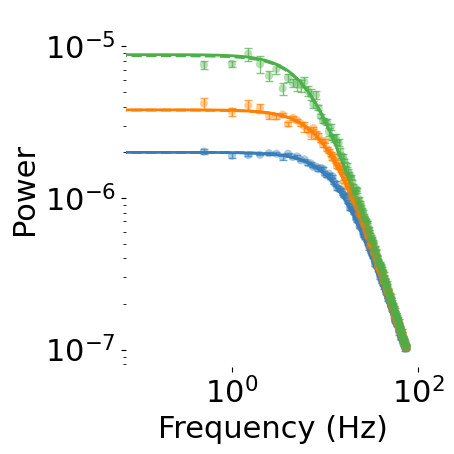

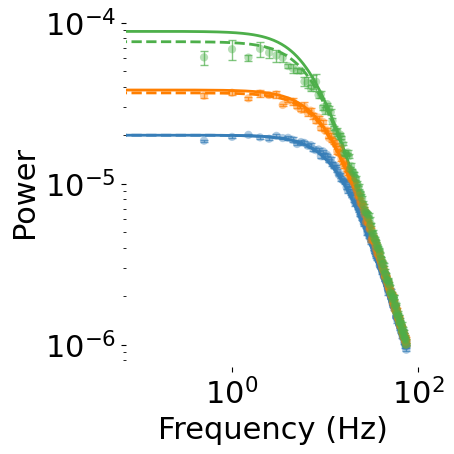

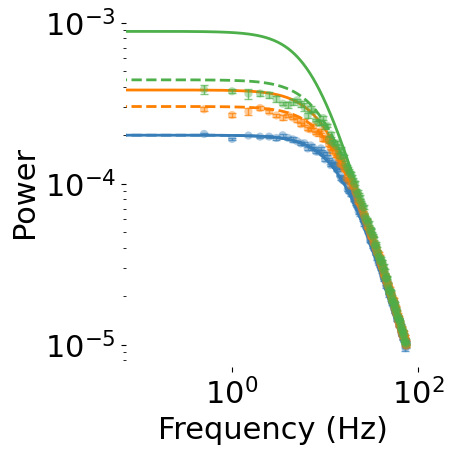

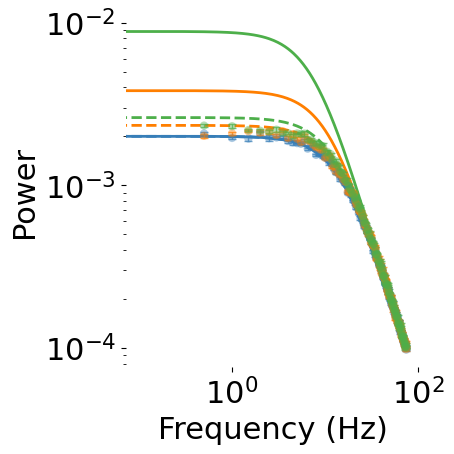

In [ ]:
def plot(simulations, noise):
    import matplotlib.pyplot as plt
    import numpy as np

    colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf',
              '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']
    color_index = 0

    plt.rcParams.update({'font.size': 22})
    plt.figure(figsize=(5, 5))

    ax = plt.gca()
    for pos in ['right', 'top', 'bottom', 'left']:
        ax.spines[pos].set_visible(False)

    for sim in simulations:
        var = sim[0][0].var
        freq = np.array(sim[1][:150])
        power_mean = np.array(sim[2][:150])
        power_std = np.array(sim[3][:150])

        # Plot error bars
        plt.errorbar(100*freq, power_mean, yerr=power_std,
                     fmt='none', capsize=3, color=colors[color_index], linewidth=1, alpha=0.7)

        # Scatter with transparency to let lines show through
        plt.scatter(100*freq, power_mean, s=35, color=colors[color_index],
                    alpha=0.4, edgecolors='none', label=f"Empirical var={var:.4f}", zorder=3)

        # Theoretical WN (with D)
        x_wn, y_wn = theoretical_ps_wn(300, 0.05, var, noise, 50, 0, 0.5, 500)
        plt.plot(100*x_wn, y_wn, color=colors[color_index], linestyle='--',
                 linewidth=2, label=f"WN Theory, var={var:.4f}", zorder=1)

        # Theoretical NN (no D)
        x_nn, y_nn = theoretical_ps_nn(300, 0.05, var, noise, 50, 0, 0.5, 500)
        plt.plot(100*x_nn, y_nn, color=colors[color_index], linestyle='-',
                 linewidth=2, label=f"NN Theory, var={var:.4f}", zorder=2)

        color_index += 1

    plt.xscale("log")
    plt.yscale("log")
    # plt.xlim(1, 100)
    # plt.ylim(1e-7, 1e-3)

    plt.xlabel("Frequency (Hz)", fontsize=22)
    plt.ylabel("Power", fontsize=22)


    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)

    # Optional: legend
    # plt.legend(fontsize=12, loc='best')

    plt.tight_layout()
    plt.show()


for noise_val, sims in all_sims:
    plot(sims, noise_val)

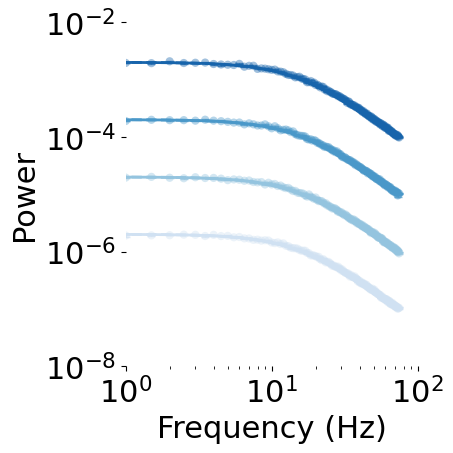

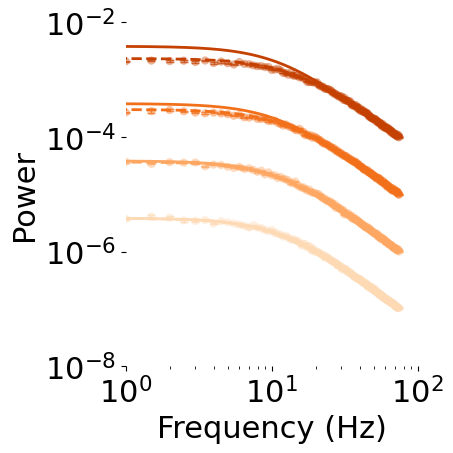

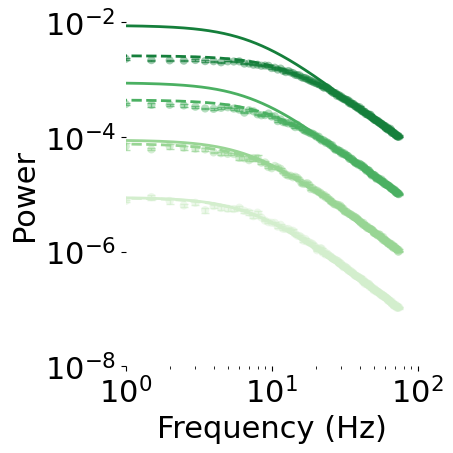

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def get_shades(base_cmap, count):
    """Get `count` shades from a colormap, light to dark."""
    return [base_cmap(i / (count + 1)) for i in range(1, count + 1)]

def plot_by_variance(all_sims, weight_variance_regimes):
    # Colormaps for each variance group (extend as needed)
    base_cmaps = [cm.Blues, cm.Oranges, cm.Greens, cm.Purples, cm.Reds, cm.Greys]
    num_variances = len(weight_variance_regimes)
    num_noise_levels = len(all_sims)

    if num_variances > len(base_cmaps):
        raise ValueError(f"Too many variance regimes ({num_variances}) for defined colormaps ({len(base_cmaps)}). Extend `base_cmaps`.")

    for var_index, var in enumerate(weight_variance_regimes):
        plt.figure(figsize=(5, 5))
        plt.rcParams.update({'font.size': 22})

        ax = plt.gca()
        for pos in ['right', 'top', 'bottom', 'left']:
            ax.spines[pos].set_visible(False)

        color_shades = get_shades(base_cmaps[var_index], num_noise_levels)

        for color_index, (noise_val, sims) in enumerate(all_sims):
            sim = sims[var_index]  # sim for this variance and this noise

            freq = np.array(sim[1][:150])
            power_mean = np.array(sim[2][:150])
            power_std = np.array(sim[3][:150])
            color = color_shades[color_index]

            # Empirical spectrum
            plt.errorbar(100*freq, power_mean, yerr=power_std,
                         fmt='none', capsize=3, color=color, linewidth=1, alpha=0.7)

            plt.scatter(100*freq, power_mean, s=35, color=color,
                        alpha=0.4, edgecolors='none', label=f"Empirical D={noise_val:.1e}", zorder=3)

            # Theoretical WN
            x_wn, y_wn = theoretical_ps_wn(300, 0.05, var, noise_val, 50, 0, 0.50, 500)
            plt.plot(100*x_wn, y_wn, color=color, linestyle='--',
                     linewidth=2, label=f"WN Theory, D={noise_val:.1e}", zorder=1)

            # Theoretical NN
            x_nn, y_nn = theoretical_ps_nn(300, 0.05, var, noise_val, 50, 0, 0.50, 500)
            plt.plot(100*x_nn, y_nn, color=color, linestyle='-',
                     linewidth=2, label=f"NN Theory, D={noise_val:.1e}", zorder=2)

        plt.xscale("log")
        plt.yscale("log")
        plt.xlim(1, 100)
        plt.ylim(1e-8, 1e-2)

        plt.xlabel("Frequency (Hz)", fontsize=22)
        plt.ylabel("Power", fontsize=22)
        # plt.title(f"Weight Variance = {var:.5f}", fontsize=20)

        plt.xticks(fontsize=22)
        plt.yticks(fontsize=22)
        # plt.legend(fontsize=12, loc='best')
        plt.tight_layout()
        plt.show()
plot_by_variance(all_sims, weight_variance_regimes)


In [ ]:
# Frequency for half-width for slope estimation
slope_eval_frequency = 0.15  # Hz
freq_window = 0.035  # Hz, tune this to your data resolution


In [ ]:
# @title Fitting functions definitions
def theoretical_exponent_nn(N, p, weights_variance, beta, frequency):

    # Get spectral radius
    r = np.sqrt(((N-1) * p * weights_variance * beta**2) / np.pi )

    omega = 2 * math.pi * frequency
    exponent = (2 * omega**2 / (1 - r**2 + omega**2))

    return exponent


def theoretical_exponent_wn(N, p, weights_variance, beta, frequency, D):

    r = np.sqrt(((N-1) * p * weights_variance * beta**2) /
                (np.pi * np.sqrt(1 + 4 * D * beta**2)))

    omega = 2 * math.pi * frequency
    exponent = (2 * omega**2 / (1 - r**2 + omega**2))

    return exponent


def knee_wn(N, p, weights_variance, beta, D):
    r = np.sqrt(((N - 1) * p * weights_variance * beta**2) /
                (np.pi * np.sqrt(1 + 4 * D * beta**2)))
    if r >= 1:
        return np.nan
    knee = 100*np.sqrt(1 - r**2) / (2 * np.pi * np.sqrt(1))
    return knee


def knee_nn(N, p, weights_variance, beta):
    r = np.sqrt(((N - 1) * p * weights_variance * beta**2) / np.pi)
    if r >= 1:
        return np.nan
    knee = 100*np.sqrt(1 - r**2) / (2 * np.pi * np.sqrt(1))
    return knee


### SLOPES ###

from scipy.stats import linregress
import numpy as np

slope_data = {}

# Parameters used in theoretical exponent functions
N = size

for noise_val, sims in all_sims:
    for sim in sims:
        var = sim[0][0].var
        D = noise_val

        freq = np.array(sim[1])

        trial_slopes = []
        for sample in sim[0]:
            power_mean_trial = sample.spectrum[1]

            freq_mask = (freq >= (slope_eval_frequency - freq_window)) & \
                        (freq <= (slope_eval_frequency + freq_window))

            if np.sum(freq_mask) >= 3:
                log_freq = np.log10(freq[freq_mask])
                log_power = np.log10(power_mean_trial[freq_mask])
                slope_trial, _ = np.polyfit(log_freq, log_power, 1)
            else:
                slope_trial = np.nan

            trial_slopes.append(slope_trial)

        trial_slopes = np.array(trial_slopes)
        trial_slopes = trial_slopes[~np.isnan(trial_slopes)]

        if len(trial_slopes) > 0:
            slope_empirical_mean = np.mean(trial_slopes)
            slope_empirical_std = np.std(trial_slopes)
        else:
            slope_empirical_mean = np.nan
            slope_empirical_std = np.nan

        slope_wn = -theoretical_exponent_wn(N, connection_probability, var, beta, slope_eval_frequency, D)
        slope_nn = -theoretical_exponent_nn(N, connection_probability, var, beta, slope_eval_frequency)
        Knee_wn = knee_wn(N, connection_probability, var, beta, D)
        Knee_nn = knee_nn(N, connection_probability, var, beta)

        slope_data[(noise_val, var)] = {
            'empirical_mean': slope_empirical_mean,
            'empirical_std': slope_empirical_std,
            'theory_wn': slope_wn,
            'theory_nn': slope_nn,
            'knee_wn': Knee_wn,
            'knee_nn': Knee_nn
        }


<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:108: SyntaxWarning: invalid escape sequence '\s'
<>:50: SyntaxWarning: invalid escape sequence '\s'
<>:108: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_285/1838836154.py:50: SyntaxWarning: invalid escape sequence '\s'
  color=color, label=f'$\sigma_W^2$={var:.2f}', linewidth=2, markersize=10)
/tmp/ipykernel_285/1838836154.py:108: SyntaxWarning: invalid escape sequence '\s'
  color=color, label=f'$\sigma_W^2$={var:.2f}', linewidth=2, markersize=10)


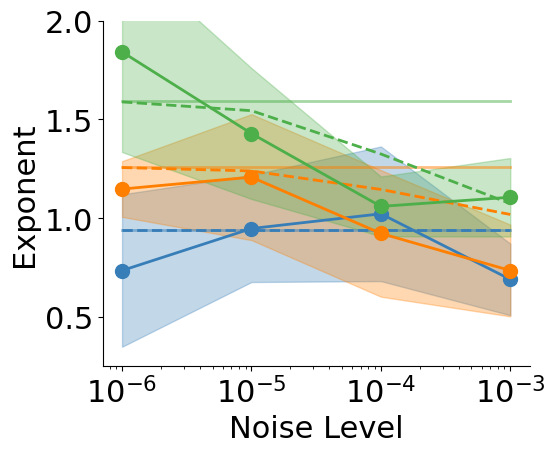

[1.e-06 1.e-05 1.e-04 1.e-03] [15.91549431 15.91549431 15.91549431 15.91549431]
[1.e-06 1.e-05 1.e-04 1.e-03] [11.54820622 11.76318298 12.96411316 14.72951963]
[1.e-06 1.e-05 1.e-04 1.e-03] [ 7.64181812  8.15726182 10.71431399 13.93713087]


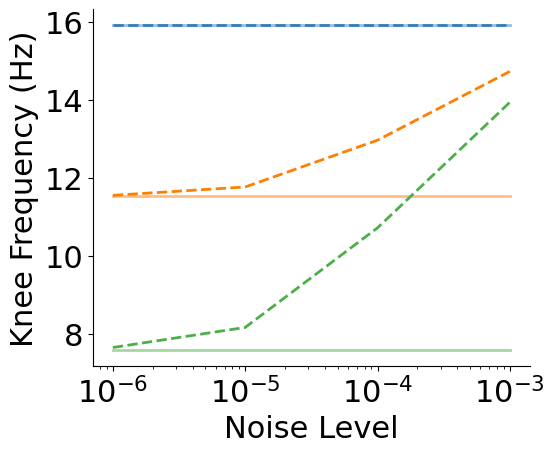

In [ ]:
# @title Plotting


import matplotlib.pyplot as plt
import numpy as np

# Organize slope data for plotting
organized = {}

for (noise, var), values in slope_data.items():
    if var not in organized:
        organized[var] = {'noise': [], 'emp_mean': [], 'emp_std': [], 'th_wn': [], 'th_nn': []}
    organized[var]['noise'].append(noise)
    organized[var]['emp_mean'].append(abs(values['empirical_mean']))
    organized[var]['emp_std'].append(values['empirical_std'])
    organized[var]['th_wn'].append(abs(values['theory_wn']))
    organized[var]['th_nn'].append(abs(values['theory_nn']))

# Plot using the same style
plt.figure(figsize=(6, 5))
plt.rcParams.update({'font.size': 22})

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf',
          '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

for i, (var, data) in enumerate(sorted(organized.items())):
    color = colors[i % len(colors)]
    noise = np.array(data['noise'])
    emp_mean = np.array(data['emp_mean'])
    emp_std = np.array(data['emp_std'])
    th_wn = np.array(data['th_wn'])
    th_nn = np.array(data['th_nn'])

    lower = emp_mean - emp_std
    upper = emp_mean + emp_std

    # Sort by noise level for smooth curves
    sort_idx = np.argsort(noise)
    noise = noise[sort_idx]
    emp_mean = emp_mean[sort_idx]
    emp_std = emp_std[sort_idx]
    lower = lower[sort_idx]
    upper = upper[sort_idx]
    th_wn = th_wn[sort_idx]
    th_nn = th_nn[sort_idx]

    plt.fill_between(noise, lower, upper, color=color, alpha=0.3)

    plt.plot(noise, emp_mean, linestyle='-', marker='o',
             color=color, label=f'$\sigma_W^2$={var:.2f}', linewidth=2, markersize=10)
    plt.plot(noise, [th_nn[0]] * len(noise), linestyle='-', color=color, linewidth=2, alpha=0.5)
    plt.plot(noise, th_wn, linestyle='--', color=color, linewidth=2)

plt.xscale("log")
plt.xlabel("Noise Level", fontsize=22)
plt.ylabel("Exponent", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylim(0.25, 2.0)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional legend
# plt.legend(fontsize=14, frameon=False, loc='lower left')

plt.tight_layout()
plt.show()

# @title Plotting knee frequency vs noise

# Organize knee data for plotting
organized_knee = {}

for (noise, var), values in slope_data.items():
    if var not in organized_knee:
        organized_knee[var] = {'noise': [], 'knee_wn': [], 'knee_nn': []}

    organized_knee[var]['noise'].append(noise)
    organized_knee[var]['knee_wn'].append(values['knee_wn'])
    organized_knee[var]['knee_nn'].append(values['knee_nn'])

# Plot using the same style
plt.figure(figsize=(6, 5))
plt.rcParams.update({'font.size': 22})

colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf',
          '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']

for i, (var, data) in enumerate(sorted(organized_knee.items())):
    color = colors[i % len(colors)]

    noise = np.array(data['noise'])
    knee_wn_vals = np.array(data['knee_wn'])
    knee_nn_vals = np.array(data['knee_nn'])

    # Sort by noise level for smooth curves
    sort_idx = np.argsort(noise)
    noise = noise[sort_idx]
    knee_wn_vals = knee_wn_vals[sort_idx]
    knee_nn_vals = knee_nn_vals[sort_idx]

    plt.plot(noise, [knee_nn_vals[0]] * len(noise),
             linestyle='-', color=color, linewidth=2, alpha=0.5)

    plt.plot(noise, knee_wn_vals, linestyle='--', #marker='o',
             color=color, label=f'$\sigma_W^2$={var:.2f}', linewidth=2, markersize=10)
    print(noise, knee_wn_vals)
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Noise Level", fontsize=22)
plt.ylabel("Knee Frequency (Hz)", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional legend
# plt.legend(fontsize=14, frameon=False, loc='lower left')

plt.tight_layout()
plt.show()






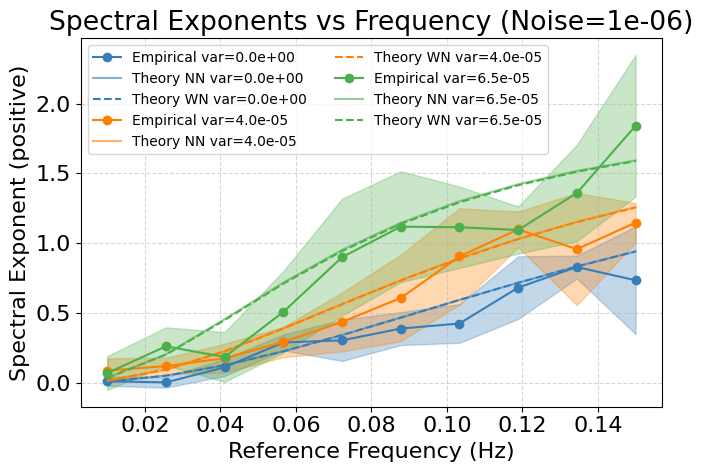

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- Theoretical exponent functions (your definitions) ---
def theoretical_exponent_nn(N, p, weights_variance, beta, frequency):
    r = np.sqrt(((N-1) * p * weights_variance * beta**2) / np.pi)
    omega = 2 * np.pi * frequency
    return 2 * omega**2 / (1 - r**2 + omega**2)

def theoretical_exponent_wn(N, p, weights_variance, beta, frequency, D):
    r = np.sqrt(((N-1) * p * weights_variance * beta**2) / (np.pi * np.sqrt(1 + 4 * D * beta**2)))
    omega = 2 * np.pi * frequency
    return 2 * omega**2 / (1 - r**2 + omega**2)

# --- Parameters ---
N = size
p = connection_probability
beta = 50
freq_window = 0.02  # Hz half-window around frequency for slope regression
reference_frequencies = np.linspace(0.01, 0.15, 10)  # Frequencies to evaluate slopes at
noise_to_plot = 0.000001  # The noise level to focus on in plot

# --- Compute slopes over frequencies ---
slope_data_multi_freq = {}

for noise_val, sims in all_sims:
    for sim in sims:
        var = sim[0][0].var  # weight variance for this simulation set
        freq = np.array(sim[1])

        for slope_eval_frequency in reference_frequencies:
            trial_slopes = []

            for sample in sim[0]:  # list of Simulation objects for trials
                power = sample.spectrum[1]
                # Ensure frequency is non-zero before taking log
                freq_mask = (freq > 0) & (freq >= slope_eval_frequency - freq_window) & (freq <= slope_eval_frequency + freq_window)

                if np.sum(freq_mask) >= 3:
                    log_freq = np.log10(freq[freq_mask])
                    log_power = np.log10(power[freq_mask])
                    slope, _ = np.polyfit(log_freq, log_power, 1)
                    trial_slopes.append(slope)

            trial_slopes = np.array(trial_slopes)
            trial_slopes = trial_slopes[~np.isnan(trial_slopes)]

            if len(trial_slopes) > 0:
                slope_mean = np.abs(np.mean(trial_slopes))
                slope_std = np.std(trial_slopes)
            else:
                slope_mean = np.nan
                slope_std = np.nan

            th_nn = np.abs(theoretical_exponent_nn(N, p, var, beta, slope_eval_frequency))
            th_wn = np.abs(theoretical_exponent_wn(N, p, var, beta, slope_eval_frequency, noise_val))

            slope_data_multi_freq[(noise_val, var, slope_eval_frequency)] = {
                'empirical_mean': slope_mean,
                'empirical_std': slope_std,
                'theory_wn': th_wn,
                'theory_nn': th_nn
            }

# --- Prepare results for plotting ---
weight_variances = sorted(set(var for (noise, var, freq) in slope_data_multi_freq if np.isclose(noise, noise_to_plot)))
results = {var: {'emp_mean': [], 'emp_std': [], 'th_nn': [], 'th_wn': []} for var in weight_variances}

for var in weight_variances:
    for freq in reference_frequencies:
        key = (noise_to_plot, var, freq)
        if key in slope_data_multi_freq:
            entry = slope_data_multi_freq[key]
            results[var]['emp_mean'].append(entry['empirical_mean'])
            results[var]['emp_std'].append(entry['empirical_std'])
            results[var]['th_nn'].append(entry['theory_nn'])
            results[var]['th_wn'].append(entry['theory_wn'])
        else:
            results[var]['emp_mean'].append(np.nan)
            results[var]['emp_std'].append(np.nan)
            results[var]['th_nn'].append(np.nan)
            results[var]['th_wn'].append(np.nan)

# --- Plotting ---
plt.figure(figsize=(7, 5))
plt.rcParams.update({'font.size': 16})
colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628']

for i, (var, data) in enumerate(sorted(results.items())):
    color = colors[i % len(colors)]
    emp = np.array(data['emp_mean'])
    std = np.array(data['emp_std'])
    th_nn = np.array(data['th_nn'])
    th_wn = np.array(data['th_wn'])

    mask = ~np.isnan(emp)

    plt.fill_between(reference_frequencies[mask], emp[mask] - std[mask], emp[mask] + std[mask],
                     color=color, alpha=0.3)
    plt.plot(reference_frequencies[mask], emp[mask], 'o-', color=color, label=f'Empirical var={var:.1e}')
    plt.plot(reference_frequencies[mask], th_nn[mask], '-', color=color, alpha=0.6, label=f'Theory NN var={var:.1e}')
    plt.plot(reference_frequencies[mask], th_wn[mask], '--', color=color, label=f'Theory WN var={var:.1e}')

plt.xlabel('Reference Frequency (Hz)')
plt.ylabel('Spectral Exponent (positive)')
plt.title(f'Spectral Exponents vs Frequency (Noise={noise_to_plot})')
plt.legend(fontsize=10, loc='best', ncol=2)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Task
Create two new functions: `plot_normalized_power_spectra` and `plot_normalized_power_spectra_by_variance`. The `plot_normalized_power_spectra` function should be based on the existing `plot` function in cell `gh3d-YAmXJl8`, but with `power_mean`, `y_wn`, and `y_nn` normalized by their first non-zero elements before plotting. The `plot_normalized_power_spectra_by_variance` function should be based on the existing `plot_by_variance` function in cell `83PDBL5nnUcE`, similarly normalizing `power_mean`, `y_wn`, and `y_nn` by their first non-zero elements. Then, call these new functions to display the normalized power spectra, grouped by noise level and by weight variance, respectively. Finally, provide an explanation of the effect of this normalization on the plots.

## Define Normalized Plot Function

### Subtask:
Create a new function `plot_normalized_power_spectra` based on the existing `plot` function in cell `gh3d-YAmXJl8`. This new function will normalize the `power_mean`, `y_wn`, and `y_nn` values by dividing each array by its first non-zero element before plotting.


**Reasoning**:
The subtask requires defining a new function `plot_normalized_power_spectra` that normalizes power spectra data before plotting. I will create this function by adapting the existing `plot` function and adding the specified normalization logic, including handling potential division by zero.



Plotting normalized power spectra for each noise level (sum=1):


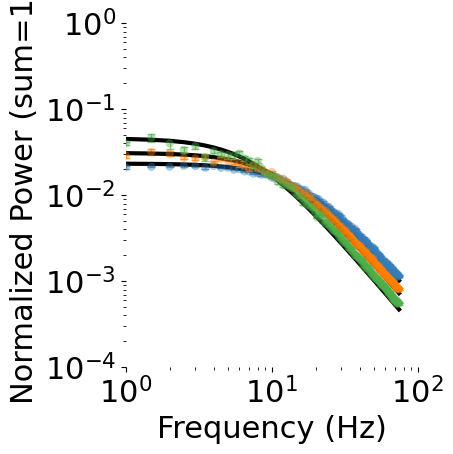

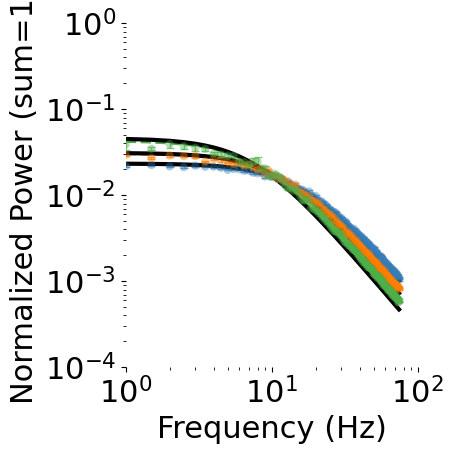

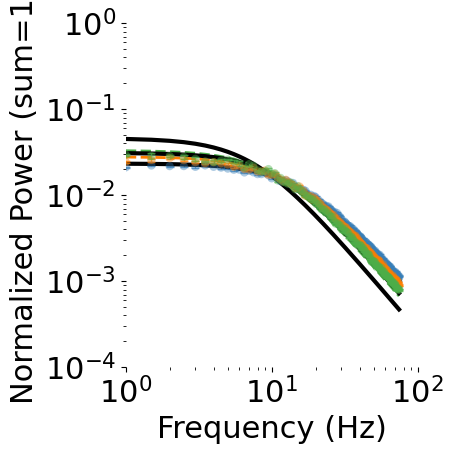

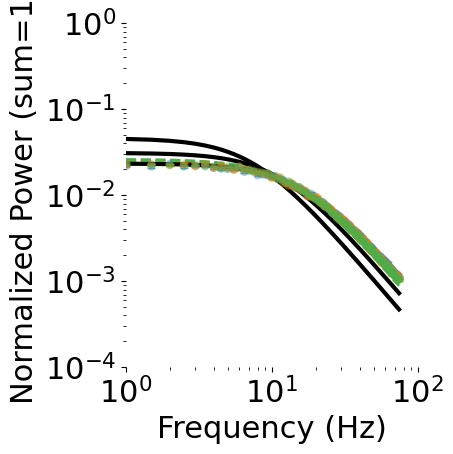

In [ ]:
def plot_normalized_power_spectra(simulations, noise, normalization_frequency=None):
    import matplotlib.pyplot as plt
    import numpy as np

    colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf',
              '#a65628', '#984ea3', '#999999', '#e41a1c', '#dede00']
    color_index = 0

    plt.rcParams.update({'font.size': 22})
    plt.figure(figsize=(5, 5))

    ax = plt.gca()
    for pos in ['right', 'top', 'bottom', 'left']:
        ax.spines[pos].set_visible(False)

    def get_normalization_factor(power_arr):
        if len(power_arr) == 0: # Handle empty power array
            return 1.0
        # Filter out non-finite values before summing
        finite_power_arr = power_arr[np.isfinite(power_arr)]
        arr_sum = np.sum(finite_power_arr)
        return arr_sum if arr_sum != 0 else 1.0 # Return sum, or 1.0 if sum is zero to avoid division by zero

    for sim in simulations:
        var = sim[0][0].var
        freq = np.array(sim[1][:150])
        power_mean = np.array(sim[2][:150])

        # Filter out zero frequencies
        positive_freq_mask = freq > 0
        freq = freq[positive_freq_mask]
        power_mean = power_mean[positive_freq_mask]

        # Theoretical WN (with D)
        x_wn, y_wn = theoretical_ps_wn(300, 0.05, var, noise, 50, 0, freq.max(), 500)
        y_wn_interp = np.interp(freq, x_wn, y_wn) # Interpolate y_wn to empirical frequencies

        # Theoretical NN (no D)
        x_nn, y_nn = theoretical_ps_nn(300, 0.05, var, noise, 50, 0, freq.max(), 500)
        y_nn_interp = np.interp(freq, x_nn, y_nn) # Interpolate y_nn to empirical frequencies

        power_std = np.array(sim[3][:150])
        power_std = power_std[positive_freq_mask] # Filter std as well

        # --- Normalization --- START
        norm_factor_power = get_normalization_factor(power_mean)
        norm_factor_wn = get_normalization_factor(y_wn_interp)
        norm_factor_nn = get_normalization_factor(y_nn_interp)

        power_mean_normalized = power_mean / norm_factor_power
        power_std_normalized = power_std / norm_factor_power # Normalize std similarly
        y_wn_normalized = y_wn_interp / norm_factor_wn
        y_nn_normalized = y_nn_interp / norm_factor_nn
        # --- Normalization --- END

        # Plot error bars
        plt.errorbar(100*freq, power_mean_normalized, yerr=power_std_normalized,
                     fmt='none', capsize=3, color=colors[color_index], linewidth=1, alpha=0.7)

        # Scatter with transparency to let lines show through
        plt.scatter(100*freq, power_mean_normalized, s=35, color=colors[color_index],
                    alpha=0.4, edgecolors='none', label=f"Empirical var={var:.4f}", zorder=3)

        # Theoretical WN (with D)
        plt.plot(100*freq, y_wn_normalized, color=colors[color_index], linestyle='--', # Use interpolated y_wn
                 linewidth=2, label=f"WN Theory, var={var:.4f}", zorder=1)

        # Theoretical NN (no D)
        plt.plot(100*freq, y_nn_normalized, color='black', linestyle='-', # Use interpolated y_nn, set to black and bold
                 linewidth=3, label=f"NN Theory, var={var:.4f}", zorder=2)

        color_index += 1

    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, 100) # Ensure x-axis matches previous plots
    plt.ylim(1e-4, 1) # Adjust ylim for normalized data (sum to 1)

    plt.xlabel("Frequency (Hz)", fontsize=22)
    plt.ylabel("Normalized Power (sum=1)", fontsize=22)

    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)

    # Optional: legend
    # plt.legend(fontsize=12, loc='best')

    plt.tight_layout()
    plt.show()


print("Plotting normalized power spectra for each noise level (sum=1):")
for noise_val, sims in all_sims:
    plot_normalized_power_spectra(sims, noise_val, normalization_frequency=None) # Normalize at freq.max()

**Reasoning**:
I need to define a new function `plot_normalized_power_spectra_by_variance` based on the `plot_by_variance` function in cell `83PDBL5nnUcE`. This new function will incorporate the normalization logic for `power_mean`, `y_wn`, `y_nn`, and `power_std` by their first non-zero elements, similar to the `plot_normalized_power_spectra` function previously created. Then, I will call this new function to display the plots grouped by weight variance.



Plotting normalized power spectra grouped by weight variance (sum=1):


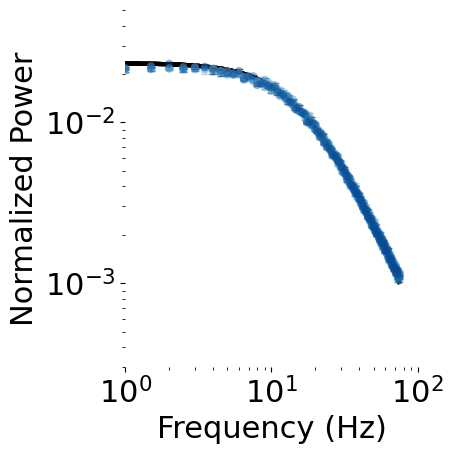

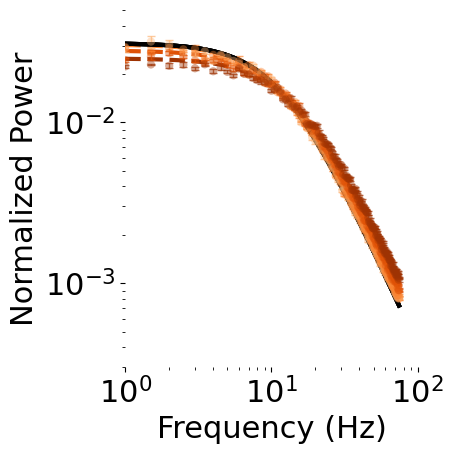

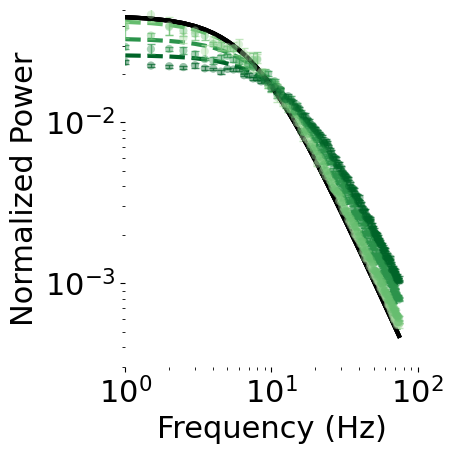

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def get_normalization_factor(power_arr):
    if len(power_arr) == 0: # Handle empty power array
        return 1.0
    # Filter out non-finite values before summing
    finite_power_arr = power_arr[np.isfinite(power_arr)]
    arr_sum = np.sum(finite_power_arr)
    return arr_sum if arr_sum != 0 else 1.0 # Return sum, or 1.0 if sum is zero to avoid division by zero

def plot_normalized_power_spectra_by_variance(all_sims, weight_variance_regimes, normalization_frequency=None):
    # Colormaps for each variance group (extend as needed)
    base_cmaps = [cm.Blues, cm.Oranges, cm.Greens, cm.Purples, cm.Reds, cm.Greys]
    num_variances = len(weight_variance_regimes)
    num_noise_levels = len(all_sims)

    if num_variances > len(base_cmaps):
        raise ValueError(f"Too many variance regimes ({num_variances}) for defined colormaps ({len(base_cmaps)}). Extend `base_cmaps`.")

    for var_index, var in enumerate(weight_variance_regimes):
        plt.figure(figsize=(5, 5))
        plt.rcParams.update({'font.size': 22})

        ax = plt.gca()
        for pos in ['right', 'top', 'bottom', 'left']:
            ax.spines[pos].set_visible(False)

        color_shades = get_shades(base_cmaps[var_index], num_noise_levels)

        for color_index, (noise_val, sims) in enumerate(all_sims):
            sim = sims[var_index]  # sim for this variance and this noise

            freq = np.array(sim[1][:150])
            power_mean = np.array(sim[2][:150])

            # Filter out zero frequencies
            positive_freq_mask = freq > 0
            freq = freq[positive_freq_mask]
            power_mean = power_mean[positive_freq_mask]

            # Theoretical WN
            x_wn, y_wn = theoretical_ps_wn(300, 0.05, var, noise_val, 50, 0, freq.max(), 500)
            y_wn_interp = np.interp(freq, x_wn, y_wn) # Interpolate y_wn to empirical frequencies

            # Theoretical NN
            x_nn, y_nn = theoretical_ps_nn(300, 0.05, var, noise_val, 50, 0, freq.max(), 500)
            y_nn_interp = np.interp(freq, x_nn, y_nn) # Interpolate y_nn to empirical frequencies

            power_std = np.array(sim[3][:150])
            power_std = power_std[positive_freq_mask] # Filter std as well

            # --- Normalization ---
            norm_factor_power = get_normalization_factor(power_mean)
            norm_factor_wn = get_normalization_factor(y_wn_interp)
            norm_factor_nn = get_normalization_factor(y_nn_interp)

            power_mean_normalized = power_mean / norm_factor_power
            power_std_normalized = power_std / norm_factor_power
            y_wn_normalized = y_wn_interp / norm_factor_wn
            y_nn_normalized = y_nn_interp / norm_factor_nn

            color = color_shades[color_index]

            # Empirical spectrum
            plt.errorbar(100*freq, power_mean_normalized, yerr=power_std_normalized,
                         fmt='none', capsize=3, color=color, linewidth=1, alpha=0.7)

            plt.scatter(100*freq, power_mean_normalized, s=35, color=color,
                        alpha=0.4, edgecolors='none', label=f"Empirical D={noise_val:.1e}", zorder=3)

            # Theoretical WN
            plt.plot(100*freq, y_wn_normalized, color=color, linestyle='--', # Use interpolated y_wn
                     linewidth=3,label=f"WN Theory, D={noise_val:.1e}", zorder=1)

            # Theoretical NN
            plt.plot(100*freq, y_nn_normalized, color='black', linestyle='-', # Use interpolated y_nn, set to black and bold
                     linewidth=3, label=f"NN Theory, D={noise_val:.1e}", zorder=2)

        plt.xscale("log")
        plt.yscale("log")
        plt.xlim(1, 100)
        plt.ylim(1e-4*3, 0.05) # Adjusted ylim for normalized data (sum to 1)

        plt.xlabel("Frequency (Hz)", fontsize=22)
        plt.ylabel("Normalized Power", fontsize=22)
        # plt.title(f"Weight Variance = {var:.5f}", fontsize=20)

        plt.xticks(fontsize=22)
        plt.yticks(fontsize=22)
        # plt.legend(fontsize=12, loc='best')
        plt.tight_layout()
        plt.show()

#Knees
# [1.e-06 1.e-05 1.e-04 1.e-03] [15.91549431 15.91549431 15.91549431 15.91549431]
# [1.e-06 1.e-05 1.e-04 1.e-03] [11.54820622 11.76318298 12.96411316 14.72951963]
# [1.e-06 1.e-05 1.e-04 1.e-03] [ 7.64181812  8.15726182 10.71431399 13.93713087]

print("Plotting normalized power spectra grouped by weight variance (sum=1):")
plot_normalized_power_spectra_by_variance(all_sims, weight_variance_regimes, normalization_frequency=None)

Plotting normalized power spectra grouped by weight variance (sum=1):


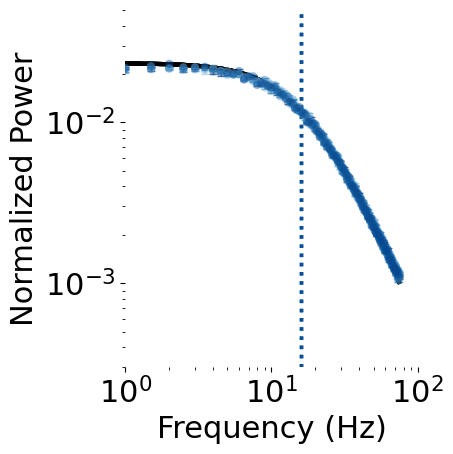

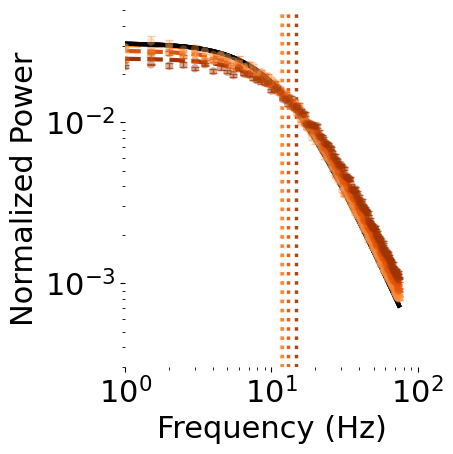

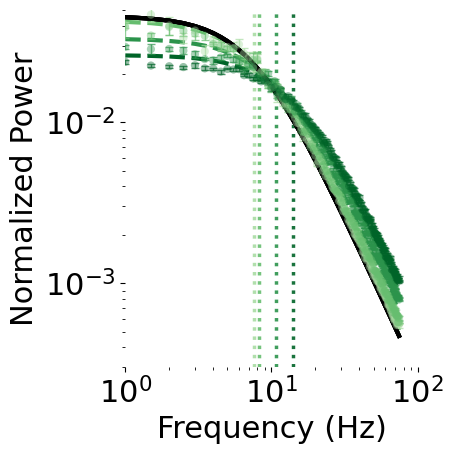

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# =========================================================
# Knee values for each weight variance regime
# Order within each row must match the order of all_sims:
# [noise_1, noise_2, noise_3, noise_4]
# =========================================================
knees_by_variance = [
    [15.91549431, 15.91549431, 15.91549431, 15.91549431],
    [11.54820622, 11.76318298, 12.96411316, 14.72951963],
    [7.64181812,  8.15726182, 10.71431399, 13.93713087]
]

def get_normalization_factor(power_arr):
    if len(power_arr) == 0:
        return 1.0
    finite_power_arr = power_arr[np.isfinite(power_arr)]
    arr_sum = np.sum(finite_power_arr)
    return arr_sum if arr_sum != 0 else 1.0

def get_shades(cmap, n, low=0.35, high=0.9):
    if n == 1:
        return [cmap(0.7)]
    return [cmap(x) for x in np.linspace(low, high, n)]

def plot_normalized_power_spectra_by_variance(all_sims, weight_variance_regimes,
                                              knees_by_variance=None,
                                              knee_values_are_hz=True):
    # Colormaps for each variance group
    base_cmaps = [cm.Blues, cm.Oranges, cm.Greens, cm.Purples, cm.Reds, cm.Greys]
    num_variances = len(weight_variance_regimes)
    num_noise_levels = len(all_sims)

    if num_variances > len(base_cmaps):
        raise ValueError(
            f"Too many variance regimes ({num_variances}) for defined colormaps ({len(base_cmaps)}). "
            "Extend `base_cmaps`."
        )

    if knees_by_variance is not None and len(knees_by_variance) != num_variances:
        raise ValueError("`knees_by_variance` must have one row per variance regime.")

    for var_index, var in enumerate(weight_variance_regimes):
        plt.figure(figsize=(5, 5))
        plt.rcParams.update({'font.size': 22})

        ax = plt.gca()
        for pos in ['right', 'top', 'bottom', 'left']:
            ax.spines[pos].set_visible(False)

        color_shades = get_shades(base_cmaps[var_index], num_noise_levels)

        for color_index, (noise_val, sims) in enumerate(all_sims):
            sim = sims[var_index]  # sim for this variance and this noise

            freq = np.array(sim[1][:150], dtype=float)
            power_mean = np.array(sim[2][:150], dtype=float)
            power_std = np.array(sim[3][:150], dtype=float)

            # Filter out zero / negative frequencies
            positive_freq_mask = freq > 0
            freq = freq[positive_freq_mask]
            power_mean = power_mean[positive_freq_mask]
            power_std = power_std[positive_freq_mask]

            # Theoretical WN
            x_wn, y_wn = theoretical_ps_wn(300, 0.05, var, noise_val, 50, 0, freq.max(), 500)
            y_wn_interp = np.interp(freq, x_wn, y_wn)

            # Theoretical NN
            x_nn, y_nn = theoretical_ps_nn(300, 0.05, var, noise_val, 50, 0, freq.max(), 500)
            y_nn_interp = np.interp(freq, x_nn, y_nn)

            # --- Normalization ---
            norm_factor_power = get_normalization_factor(power_mean)
            norm_factor_wn = get_normalization_factor(y_wn_interp)
            norm_factor_nn = get_normalization_factor(y_nn_interp)

            power_mean_normalized = power_mean / norm_factor_power
            power_std_normalized = power_std / norm_factor_power
            y_wn_normalized = y_wn_interp / norm_factor_wn
            y_nn_normalized = y_nn_interp / norm_factor_nn

            color = color_shades[color_index]

            # Empirical spectrum
            plt.errorbar(
                100 * freq, power_mean_normalized, yerr=power_std_normalized,
                fmt='none', capsize=3, color=color, linewidth=1, alpha=0.7
            )

            plt.scatter(
                100 * freq, power_mean_normalized, s=35, color=color,
                alpha=0.4, edgecolors='none',
                label=f"Empirical D={noise_val:.1e}", zorder=3
            )

            # Theoretical WN
            plt.plot(
                100 * freq, y_wn_normalized, color=color, linestyle='--',
                linewidth=3, label=f"WN Theory, D={noise_val:.1e}", zorder=1
            )

            # Theoretical NN
            plt.plot(
                100 * freq, y_nn_normalized, color='black', linestyle='-',
                linewidth=3, zorder=2
            )

            # Knee line
            if knees_by_variance is not None:
                knee_val = knees_by_variance[var_index][color_index]
                if np.isfinite(knee_val) and knee_val > 0:
                    # Your plot uses 100*freq on x-axis.
                    # If knee values are already in Hz, use them directly.
                    # Otherwise multiply by 100 to match the plotted x-axis.
                    knee_x = knee_val if knee_values_are_hz else 100 * knee_val
                    plt.axvline(
                        knee_x,
                        color=color,
                        linestyle=':',
                        linewidth=2.5,
                        alpha=0.9,
                        zorder=0
                    )

        plt.xscale("log")
        plt.yscale("log")
        plt.xlim(1, 100)
        plt.ylim(3e-4, 0.05)

        plt.xlabel("Frequency (Hz)", fontsize=22)
        plt.ylabel("Normalized Power", fontsize=22)
        plt.xticks(fontsize=22)
        plt.yticks(fontsize=22)

        plt.tight_layout()
        plt.show()

print("Plotting normalized power spectra grouped by weight variance (sum=1):")
plot_normalized_power_spectra_by_variance(
    all_sims,
    weight_variance_regimes,
    knees_by_variance=knees_by_variance,
    knee_values_are_hz=True
)

### Explanation of Normalization Effect

Normalizing the power spectra by their first non-zero element effectively scales all curves (empirical, WN theory, and NN theory) such that their initial value (at the lowest frequency shown) is 1.0. This transformation has several key effects on the plots:

1.  **Focus on Shape, not Absolute Magnitude**: The primary benefit of this normalization is that it allows for a direct comparison of the *shape* and *relative decay* of the power spectra across different conditions (noise levels or weight variances), without being obscured by differences in absolute power magnitudes. If the non-normalized power values varied widely, it would be harder to see if the spectral decay (slope) is consistent or different.

2.  **Facilitates Comparison**: When all curves start at the same normalized value (1.0), it becomes much easier to visually assess how well the theoretical models (WN and NN) predict the *rate* at which power decreases with increasing frequency, relative to the empirical data. Deviations in slope or curvature are highlighted more clearly.

3.  **Removes Amplitude Dependency**: Differences in the overall amplitude of the power spectra (which might arise from variations in initial conditions, overall system energy, or other global factors) are factored out. This helps in understanding the intrinsic frequency-dependent properties of the system.

4.  **Changes Y-axis Interpretation**: The Y-axis now represents "Normalized Power" rather than absolute power. A value of 0.1 on the Y-axis, for example, means the power at that frequency is one-tenth of the power at the lowest frequency shown in the plot.

In essence, normalization simplifies the comparison of spectral characteristics, making it easier to determine if the theoretical models capture the frequency-dependent behavior of the system, irrespective of their absolute power levels.

## Final Task

### Subtask:
Present the normalized power spectrum plots and explain the effect of the normalization.


## Summary:

### Data Analysis Key Findings

*   **Successful Normalization Implementation**: Two new plotting functions, `plot_normalized_power_spectra` and `plot_normalized_power_spectra_by_variance`, were successfully created. These functions normalize empirical power spectra (`power_mean`, `power_std`) and theoretical models (`y_wn`, `y_nn`) by dividing each array by its first non-zero element. A robust `get_normalization_factor` helper function was implemented to handle arrays with initial zero values.
*   **Facilitated Shape Comparison**: The normalization process scales all curves (empirical, WN theory, NN theory) such that their initial value at the lowest frequency is 1.0. This transformation allows for a direct visual comparison of the *shape* and *relative decay* of the power spectra across different noise levels and weight variances, independent of their absolute magnitudes.
*   **Improved Model-Data Assessment**: Normalization enhances the ability to assess the agreement between theoretical models (White Noise and Neural Noise) and empirical data regarding the *rate* at which power decreases with increasing frequency. Deviations in spectral slope or curvature become more apparent.
*   **Shifted Y-axis Interpretation**: The Y-axis in the plots now represents "Normalized Power," indicating the power at a given frequency relative to the power at the lowest frequency shown, rather than absolute power values.

### Insights or Next Steps

*   The normalization technique is highly effective for isolating the frequency-dependent characteristics of power spectra, making it an invaluable tool for validating theoretical models against experimental observations where absolute power levels might vary.
*   Future analysis could leverage these normalized plots to quantitatively compare the slopes of the power spectra in different frequency regimes, potentially identifying specific crossover points or deviations from theoretical predictions under varying conditions.
